# Проверка гипотез в бизнесе

* Автор: Федорова Марина Вячеславовна


<a class="ancor" id="1-bullet"></a>
### Цели и задачи проекта
Используем датасеты с данными о пользователях сервиса, их поездках за один год, а также стоимости услуг в подписках и проанализируем демографию пользователей и особенности использования самокатов, а также определим возможную выгоду от распространения платной подписки на самокаты.

<a class="ancor" id="2-bullet"></a>
### Описание данных

В проекте будут использованы датасеты:

*Таблица с пользователями* `users_go.csv`

- `user_id` — уникальный идентификатор пользователя.

- `name` — имя пользователя.

- `age` — возраст.

- `city` — город.

- `subscription_type` — тип подписки: `free`, `ultra`.


*Таблица с поездками* `rides_go.csv`

- `user_id` — уникальный идентификатор пользователя.

- `distance` — расстояние в метрах, которое пользователь проехал в текущей сессии.

- `duration` — продолжительность сессии в минутах, то есть время с того момента, как пользователь нажал кнопку «Начать поездку», до того, как он нажал кнопку «Завершить поездку».

- `date` — дата совершения поездки.


*Таблица с подписками* `subscriptions_go.csv`

- `subscription_type` — тип подписки.

- `minute_price` — стоимость одной минуты поездки по этой подписке.

- `start_ride_price` — стоимость начала поездки.

- `subscription_fee` — стоимость ежемесячного платежа.

<a class="ancor" id="20-bullet"></a>
### Содержание проекта

[Цели и задачи проекта](#1-bullet)

[Описание данных](#2-bullet)

[1. Загрузка данных и знакомство с ними](#3-bullet)

[2. Предобработка данных](#4-bullet)

   * [2.1 Преобразование типа данных](#5-bullet)
   
   * [2.2 Обработка пропущенных значений и дубликатов](#6-bullet)
    
[3. Исследовательский анализ данных (EDA)](#7-bullet)

[4. Объединение данных](#8-bullet)

[5. Подсчёт выручки](#9-bullet)

[6. Проверка гипотез](#10-bullet)

   * [6.1 Длительность для пользователей с подпиской и без](#11-bullet)
   
   * [6.2 Длительность поездки: больше или меньше критического значения](#12-bullet)
   
   * [6.3 Прибыль от пользователей с подпиской и без](#13-bullet)
   
[7. Распределения](#14-bullet)

   * [7.1 Расчёт выборочного среднего и стандартного отклонения](#15-bullet)
   
   * [7.2 Вычисление значения функции распределения в точке (CDF)](#16-bullet)
   
   * [7.3 Вероятность для интервала (CDF)](#17-bullet)
   
   * [7.4 Определение критической дистанции поездок (PPF)](#18-bullet)
   
[Итоговый вывод](#19-bullet)

---
<a class="ancor" id="3-bullet"></a>
## 1. Загрузка данных и знакомство с ними


Загрузим необходимые библиотеки для анализа и данные из датасетов.


In [1]:
# Импортируем библиотеку pandas
import pandas as pd

# Импортируем библиотеку для визуализации
import matplotlib.pyplot as plt

# Импортируем библиотеку scipy.stats
import scipy.stats as st

In [2]:
# Загружаем данные из датасетов users_go.csv, rides_go.csv и subscriptions_go.csv
df_users_go = pd.read_csv('https://code.s3.yandex.net/datasets/users_go.csv')
df_rides_go = pd.read_csv('https://code.s3.yandex.net/datasets/rides_go.csv')
df_subscriptions_go = pd.read_csv('https://code.s3.yandex.net/datasets/subscriptions_go.csv')

In [3]:
# Выводим информацию о 'df_users_go'
df_users_go.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB


In [4]:
# Выводим информацию о 'df_rides_go'
df_rides_go.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB


In [5]:
# Выводим информацию о 'df_subscriptions_go'
df_subscriptions_go.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 192.0+ bytes


In [6]:
# Выводим первые пять строк датафреймов
display(df_users_go.head())
display(df_rides_go.head())
display(df_subscriptions_go.head())

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


In [7]:
# Определим количество строк в каждом из датафреймов
display(df_users_go.shape[0], df_rides_go.shape[0], df_subscriptions_go.shape[0])

1565

18068

2

[Назад к содержимому](#20-bullet)

---
<a class="ancor" id="4-bullet"></a>
## 2. Предобработка данных

<a class="ancor" id="5-bullet"></a>
### 2.1. Преобразование типа данных
Прежде чем начать анализ, приведём столбец `date` в датафрейме `df_rides_go` к типу даты

In [8]:
df_rides_go['date'] = pd.to_datetime(df_rides_go['date'])

На основе столбца `date` создадим новый столбец `month`, содержащий номер месяца. Это нужно для последующей группировки данных и анализа сезонных трендов.

In [9]:
 df_rides_go['month'] = df_rides_go['date'].dt.month

[Назад к содержимому](#20-bullet)

<a class="ancor" id="6-bullet"></a>
### 2.2. Обработка пропущенных значений и дубликатов

In [10]:
# Проверим пропуски и полные дубликаты в датафрейме
missing_value = df_users_go.isna().sum().sum()
duplicates = df_users_go.duplicated().sum()
display (missing_value, duplicates)

0

31

In [11]:
# Удаляем дубликаты в датафрейме 
df_users_go = df_users_go.drop_duplicates()
df_users_go.shape[0]

1534

In [12]:
# Округлим столбец 'duration' до целых чисел
df_rides_go['duration'] = round(df_rides_go['duration']).astype('int64')

После обработки данных в датафрейме `df_users_go` осталось 1534 строк.

[Назад к содержимому](#20-bullet)

---
<a class="ancor" id="7-bullet"></a>
## 3. Исследовательский анализ данных (EDA)

Изучим и визуализируем информацию о географии и демографии сервиса, а также попробуем найти закономерности в дистанциях и длительности поездок.

In [13]:
# Изучим количество пользователей в каждом из городов
users_by_city_count = df_users_go['city'].value_counts() 
users_by_city_count

Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: city, dtype: int64

In [14]:
# Изузим количество пользователей для каждого типа подписки
subscription_type_count = df_users_go['subscription_type'].value_counts()
subscription_type_count

free     835
ultra    699
Name: subscription_type, dtype: int64

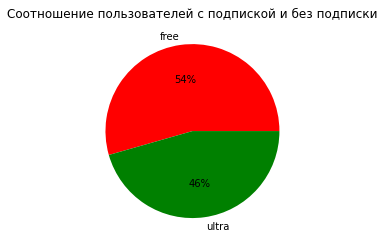

In [15]:
# Построим круговую диаграмму
subscription_type_count.plot(
    kind='pie',
    title='Соотношение пользователей с подпиской и без подписки',
    autopct='%.0f%%',
    ylabel='',
    colors=['red', 'green']
)

plt.show()

Построим гистограмму возрастов пользователей самокатов. Используем количество бинов, равное разности максимального и минимального значений возраста.

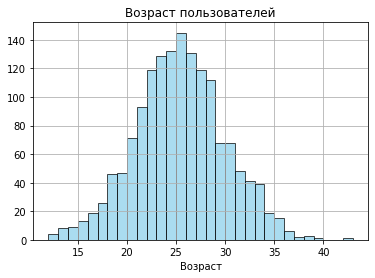

In [16]:
# Определим количество бинов
n_bins = df_users_go['age'].max() - df_users_go['age'].min()

# Строим гистограмму
df_users_go['age'].hist( 
    bins=n_bins, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.7
    )

# Настраиваем оформление графика
plt.title('Возраст пользователей')
plt.xlabel('Возраст')

# Выводим график
plt.show()

Рассчитаем долю несовершеннолетних (возрастом менее 18 лет) пользователей самокатов.

In [17]:
underage_users = df_users_go[df_users_go['age'] < 18]
users_under_18_ratio = round(underage_users.shape[0] / df_users_go.shape[0] * 100)
print(f'Доля несовершеннолетних пользователей самокатов составляет {users_under_18_ratio}%.')

Доля несовершеннолетних пользователей самокатов составляет 5%.


Расчитаем среднее значение и стандартное отклонение длительности поездки, а также 25-й и 75-й процентили длительности поездки.

In [18]:
# Изучим длителтьность поездок
duration_mean = round(df_rides_go['duration'].mean())
duration_std = round(df_rides_go['duration'].std())

duration_pct25 = round(df_rides_go['duration'].quantile(0.25))
duration_pct75 = round(df_rides_go['duration'].quantile(0.75))

print(f'Средняя длительность поездки {duration_mean} минут со стандартным отклонением {duration_std}. Основная часть поездок занимает от {duration_pct25} до {duration_pct75} минут.')

Средняя длительность поездки 18 минут со стандартным отклонением 6. Основная часть поездок занимает от 14 до 22 минут.


#### Промежуточный вывод
Проанализировав данные, можно сделать следующие выводы:
* Лидером среди пользователей самокатов является Пятигорск 219 пользователей. Москва же находится в самом конце списка - 168 пользователей.
* Пользователей с подпиской на 8 % меньше, чем пользователей, которые не оформили подписку.
* Возраст пользователей в большей части варьируется от 22 до 29 лет. Также есть и несовершенолетние пользователи, их доля составляет 5 %.
* Средняя длительность поездки 18 минут со стандартным отклонением 6. Основная часть поездок занимает от 14 до 22 минут.

[Назад к содержимому](#20-bullet)

---
<a class="ancor" id="8-bullet"></a>
## 4. Объединение данных
Объединим данные из трёх датасетов в один датафрейм.

In [19]:
df = df_users_go.merge(df_rides_go, on='user_id', how='left')

In [20]:
df = df.merge(df_subscriptions_go, on='subscription_type', how='left')

In [21]:
# Выводим первые строки датафрейма
display(df.head())

# Выводим количество строк и столбцов в объединённом датафрейме
n_rows, n_cols = df.shape
print(f'В полученном датафрейме {n_rows} строк и {n_cols} столбцов.')

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,26,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,16,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,19,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26,2021-08-28,8,6,0,199


В полученном датафрейме 18068 строк и 12 столбцов.


Создадим два вспомогательных датафрейма на основе `df`: первый только для пользователей с подпиской `df_ultra` и второй только для пользователей без подписки `df_free`.

In [22]:
df_ultra = df[df['subscription_type'] == 'ultra']
df_free = df[df['subscription_type'] == 'free']

Построим гистограмму распределения длительности поездок duration для пользователей с подпиской и без. Также рассчитаем среднюю длительность поездки для пользователей с подпиской и без.

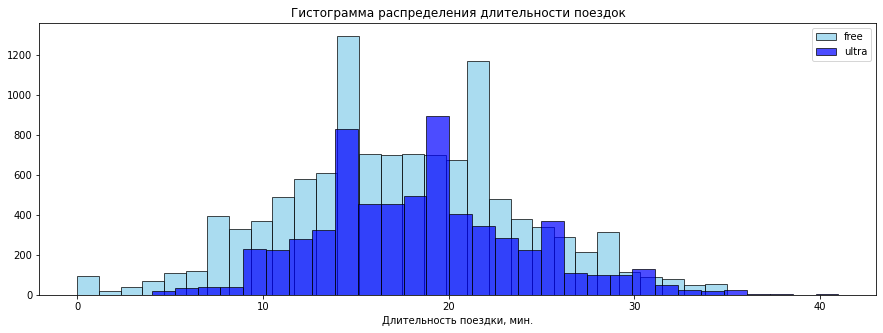

Средняя длительность поездки для пользователей без подписки 17 мин, а для пользователей с подпиской 19 мин


In [23]:
# Гистограмма длительности поездки для пользователей с подпиской и без
plt.figure(figsize=(15, 5))

# Строим гистограмму
df_free['duration'].hist( 
    bins=30,
    label='free',
    color='skyblue', 
    edgecolor='black', 
    alpha=0.7
    )
df_ultra['duration'].hist( 
    bins=30,
    label='ultra',
    color='blue', 
    edgecolor='black', 
    alpha=0.7
    )

# Настраиваем оформление графика
plt.title('Гистограмма распределения длительности поездок')
plt.xlabel('Длительность поездки, мин.')
plt.legend()

# Добавляем сетку графика
plt.grid()
# Выводим график
plt.show()

# Расчет и вывод на экран средней длительности поездки для пользователей с подпиской и без
mean_duration_free = round(df_free['duration'].mean())
mean_duration_ultra = round(df_ultra['duration'].mean())
print(f'Средняя длительность поездки для пользователей без подписки {mean_duration_free} мин, а для пользователей с подпиской {mean_duration_ultra} мин')

#### Промежеточный вывод
После объединения датафрейм содержит 18068 строк и 12 столбцов.

Средняя длительность для пользователей с подпиской приблизительно на 2 минуты больше, чем без подписки. У пользователей без платной подписки больший разброс по времени поездок. 

[Назад к содержимому](#20-bullet)

---
<a class="ancor" id="9-bullet"></a>
## 5. Подсчёт выручки

In [24]:
# Сгруппируем данные по 'user_id', 'name', 'subscription_type' и 'month'
df_gp = df.groupby(['user_id', 'name', 'subscription_type', 'month'], as_index=False)

Создадим новый датафрейм df_agg. В нём для каждой группы рассчитаем и добавим в датафрейм следующие значения:

* `total_distance` — суммарное растояние в метрах.
* `total_duration` — суммарная длительность поездки.
* `rides_count` — количество поездок.
* `subscription_type` — первое значение в группе для столбца по типу подписки.
* `minute_price` — первое значение в группе для столбца со стоимостью одной минуты поездки.
* `start_ride_price` — первое значение в группе для столбца со стоимостью начала поездки.
* `subscription_fee` — первое значение в группе для столбца со стоимостью ежемесячного платежа.

In [25]:
df_agg = df_gp.agg(
    total_distance=('distance', 'sum'),
    total_duration=('duration', 'sum'),
    rides_count=('duration', 'count'),
    subscription_type=('subscription_type', 'first'),
    minute_price=('minute_price', 'first'),
    start_ride_price=('start_ride_price', 'first'),
    subscription_fee=('subscription_fee', 'first'),
)

In [26]:
# Создадим функцию для расчёта месячной выручки
def calculate_monthly_revenue(row):
    monthly_revenue = row['start_ride_price'] * row['rides_count'] + row['minute_price'] * row['total_duration'] + row['subscription_fee']
    return monthly_revenue

In [27]:
# Применим функцию к каждой строке
df_agg['monthly_revenue'] = df_agg.apply(calculate_monthly_revenue, axis=1)

Исследуем полученные значения выручки. Найдём пользователя с максимальной суммарной выручкой за весь период наблюдения.

In [28]:
# 1. Группируем по пользователю, считаем суммарную выручку за все месяцы
user_total_revenue = df_agg.groupby(['user_id', 'name'])['monthly_revenue'].sum().reset_index()

# 2. Находим пользователя с максимальной суммарной выручкой
top_user = user_total_revenue.loc[user_total_revenue['monthly_revenue'].idxmax()]

# 3. Получаем user_id и name топ‑пользователя
top_user_id = top_user['user_id']
top_user_name = top_user['name']

# 4. Фильтруем исходный датафрейм по этому пользователю, чтобы получить данные по месяцам
user_monthly_data = df_agg[
    (df_agg['user_id'] == top_user_id) & 
    (df_agg['name'] == top_user_name)
][['user_id', 'name', 'month', 'rides_count', 'monthly_revenue']]

# 5. Сортируем по месяцу и выводим результат
user_monthly_data = user_monthly_data.sort_values('month')
display(user_monthly_data)

,user_id,name,month,rides_count,monthly_revenue
8877,1236,Александр,1,2,228
8878,1236,Александр,2,3,614
8879,1236,Александр,3,5,762
8880,1236,Александр,4,1,202
8881,1236,Александр,5,3,574
8882,1236,Александр,6,1,282
8883,1236,Александр,7,1,290
8884,1236,Александр,8,2,452
8885,1236,Александр,9,1,122
8886,1236,Александр,10,3,430


Самую большую выручку приносит пользователь с id 1236.

[Назад к содержимому](#20-bullet)

---
<a class="ancor" id="10-bullet"></a>
## 6. Проверка гипотез

Напишем вспомогательную функцию, которая будет интерпретировать результаты статистического теста на основе p-value и заданного уровня значимости (α-уровня).

In [29]:
def print_stattest_results(p_value:float, alpha:float = 0.05):
    if p_value < alpha:
        print (f'Полученное значение p_value={p_value} меньше критического уровня alpha={alpha}. Принимаем альтернативную гипотезу.')
    else:
        print (f'Полученное значение p_value={p_value} больше критического уровня alpha={alpha}. Опровергнуть нулевую гипотезу нельзя.')

print_stattest_results(p_value=0.0001)
print_stattest_results(p_value=0.1)

Полученное значение p_value=0.0001 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Полученное значение p_value=0.1 больше критического уровня alpha=0.05. Опровергнуть нулевую гипотезу нельзя.


<a class="ancor" id="11-bullet"></a>
### 6.1. Длительность для пользователей с подпиской и без

Важно понять, тратят ли пользователи с подпиской больше времени на поездки? Сформулируем нулевую и альтернативную гипотезы:

`Нулевая гипотеза (Н0)`: Среднее время поездки у пользователей с подпиской и без подписки одинаковое.

`Альтернативная гипотеза (Н1)`: Среднее время поездки у пользователей с подпиской больше, чем у пользователей без подписки.

In [30]:
ultra_duration = df_ultra['duration']
free_duration = df_free['duration']

results = st.ttest_ind(ultra_duration, free_duration, alternative='greater') # Укажите подходящий инструмент здесь
p_value = results.pvalue
print_stattest_results(p_value)
ultra_mean_duration = round(df_ultra['duration'].mean(), 2)
free_mean_duration = round(df_free['duration'].mean(), 2)

print(f'Средняя длительность поездки тарифа Ultra {ultra_mean_duration}')
print(f'Средняя длительность поездки тарифа Free {free_mean_duration}')

Полученное значение p_value=3.1600689435611813e-35 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Средняя длительность поездки тарифа Ultra 18.55
Средняя длительность поездки тарифа Free 17.39


[Назад к содержимому](#20-bullet)

<a class="ancor" id="12-bullet"></a>
### 6.2. Длительность поездки: больше или меньше критического значения

Проанализируем ещё одну важную продуктовую гипотезу. Расстояние одной поездки в 3130 метров — оптимальное с точки зрения износа самоката. Можно ли сказать, что расстояние, которое проезжают пользователи с подпиской за одну поездку, меньше 3130 метров?

Сформулируем нулевую и альтернативную гипотезы:

`Нулевая гипотеза (Н0)`: Средняя дистанция поездки у пользователей с подпиской равна 3130 м.

`Альтернативная гипотеза (Н1)`: Средняя дистанция поездки у пользователей с подпиской больше 3130 м.

In [31]:
null_hypothesis = 3130
ultra_distance = df_ultra['distance']

results = st.ttest_1samp(ultra_distance, null_hypothesis, alternative='greater')
p_value = results.pvalue
print_stattest_results(p_value)

Полученное значение p_value=0.9195368847849785 больше критического уровня alpha=0.05. Опровергнуть нулевую гипотезу нельзя.


[Назад к содержимому](#20-bullet)

<a class="ancor" id="13-bullet"></a>
### 6.3. Прибыль от пользователей с подпиской и без

Проверим гипотезу о том, что выручка от пользователей с подпиской выше, чем выручка от пользователей без подписки.

Сформулируем нулевую и альтернативную гипотезы:

`Нулевая гипотеза (Н0)`: Средняя месячная выручка у пользователей с подпиской и без подписки одинаковая.

`Альтернативная гипотеза (Н1)`: Средняя месячная выручка у пользователей с подпиской выше, чем у пользователей без подписки.

In [32]:
revenue_ultra = df_agg['monthly_revenue'][df_agg['subscription_type'] == 'ultra']
revenue_free = df_agg['monthly_revenue'][df_agg['subscription_type'] == 'free']

results = st.ttest_ind(revenue_ultra, revenue_free, alternative='greater')
p_value = results.pvalue
print_stattest_results(p_value)

mean_revenue_ultra = round(df_agg['monthly_revenue'][df_agg['subscription_type'] == 'ultra'].mean())
mean_revenue_free = round(df_agg['monthly_revenue'][df_agg['subscription_type'] == 'free'].mean())

print(f'Средняя выручка подписчиков Ultra {mean_revenue_ultra} руб')
print(f'Средняя выручка подписчиков Free {mean_revenue_free} руб')

Полученное значение p_value=1.7274069878387966e-37 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Средняя выручка подписчиков Ultra 359 руб
Средняя выручка подписчиков Free 322 руб


#### Промежуточный вывод
Проверка гипотез показала:

* Пользователи тарифа Ultra действительно статистически значимо имеют большую длительность поездки - 18.55.
* Также есть основания утверждать, что средняя дистанция поездки у пользователей с подпиской равна 3130 м.
* Средняя месячная выручка у пользователей с подпиской выше (359 руб), чем у пользователей без подписки (322 руб).

[Назад к содержимому](#20-bullet)

---
<a class="ancor" id="14-bullet"></a>
## 7. Распределения

В компании возникла идея предлагать дополнительную скидку подписчикам, совершающим длительные поездки. Оценим долю поездок, продолжительность которых более 30 минут.

Смоделируем длительность поездки с помощью нормального распределения, используя в качестве параметров выборочное среднее и стандартное отклонение из доступных данных о поездках.

<a class="ancor" id="15-bullet"></a>
### 7.1. Расчёт выборочного среднего и стандартного отклонения

In [33]:
# Вычисляем среднее значение
mu = df_ultra['duration'].mean()

# Вычисляем стандартное отклонение
sigma = df_ultra['duration'].std()

# Задаём целевое время
target_time = 30

# Делаем вывод
print(f'Средняя длительность поездки {round(mu, 1)}, стандартное отклонение {round(sigma, 1)}.')

Средняя длительность поездки 18.5, стандартное отклонение 5.6.


[Назад к содержимому](#20-bullet)

<a class="ancor" id="16-bullet"></a>
### 7.2. Вычисление значения функции распределения в точке (CDF)

Если вычислить значение функции распределения в точке, это позволит узнать вероятность того, что случайная величина примет значение меньше заданного либо равное ему. Используем CDF для нахождения накопленной вероятности.

In [34]:
# Вычисляем вероятность того, что случайная величина будет меньше указанного значения или равна ему

duration_norm_dist  = st.norm(mu, sigma)
prob = round(1 - duration_norm_dist.cdf(target_time), 3)
print(f'Вероятность поездки более 30 минут {prob}')

Вероятность поездки более 30 минут 0.02


[Назад к содержимому](#20-bullet)

<a class="ancor" id="17-bullet"></a>
### 7.3. Вероятность для интервала (CDF)

Коллеги посчитали, что процент пользователей, для которых будет показана скидка, недостаточно большой и вряд ли поможет в увеличении лояльности клиентов. Проверим какой процент пользователей совершает поездки в интервале от 20 до 30 минут.

In [35]:
# Определяем границы интервала
low = 20
high = 30

# Вычисляем вероятность попадания в интервал
prob_interval = round((duration_norm_dist.cdf(high) - duration_norm_dist.cdf(low)), 3)

# Выводим результат
print(f'Вероятность того, что пользователь совершит поездку длительностью от {low} до {high} минут: {prob_interval}')

Вероятность того, что пользователь совершит поездку длительностью от 20 до 30 минут: 0.377


[Назад к содержимому](#20-bullet)

<a class="ancor" id="18-bullet"></a>
### 7.4. Определение критической дистанции поездок (PPF)

Длительные поездки могут негативно сказываться на сроке службы самоката. В связи с этим принято решение установить критическую дистанцию, превышение которой будет сопровождаться дополнительной платой. Для этого необходимо определить расстояние, которое превышается только в 10% поездок (90-й процентиль).

Смоделируем распределение длительности поездок, предполагая, что оно подчиняется нормальному закону, и рассчитаем критическую дистанцию, ниже которой находится 90% всех поездок.

In [36]:
# Вычисляем среднее значение
mu = df['distance'].mean()

# Вычисляем стандартное отклонение
sigma = df['distance'].std()

# Вероятность, для которой хотим найти значение (90% случаев)
target_prob = 0.90

# Создаём объект нормального распределения
distance_norm = st.norm(mu, sigma)

# Рассчитываем критическую дистанцию для заданного процентиля поездок
critical_distance = distance_norm.ppf(target_prob)

print(f'{100 * target_prob} % поездок имеют дистанцию ниже критического значения {critical_distance:.2f} М.')

90.0 % поездок имеют дистанцию ниже критического значения 4501.94 М.


[Назад к содержимому](#20-bullet)

<a class="ancor" id="19-bullet"></a>
## Итоговый вывод:

После проверки гипотез можно сделать вывод о том, что у пользователей с подпиской средняя месячная подписка выше. 

Также выяснили, что подписчики не превышают среднюю дистанцию поездок равной в 3130 м, что оптимально с точки зрения износа самоката.

Пользователей с подпиской на 8 % меньше, чем пользователей, которые не оформили подписку.

Возраст пользователей в большей части варьируется от 22 до 29 лет.

Средняя длительность для пользователей с подпиской приблизительно на 2 минуты больше, чем без подписки.

Вероятность в практически 38 % пользователей, совершающих поездки в интервале от 20 до 30 минут дает возможность провести промоакцию на такой выборке, что поможет вырастить лояльность продукту.

[Назад к содержимому](#20-bullet)